In [123]:
#importing required library
import requests
import pandas as pd
import re
import plotly.express as px
import numpy as np



In [44]:
# API Config Stuffs
def get_attr_value(attrs, name):
    for attr in attrs:
        if attr.get("name") == name:
            return attr.get("value")
    return None


In [45]:
def fetch_data(page):
    url = "https://jiji.ng/api_web/v1/listing"

    params = {
        "slug": "houses-apartments-for-sale",
        "page": page,
        "webp": True
    }

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    try:
        response = requests.get(
            url,
            headers=headers,
            params=params
        )

        data = response.json()

    except requests.RequestException:
        print(f"[Page {page}] Request Error")
        return []

    except ValueError:
        print(f"[Page {page}] Decode Error")
        return []

    adverts_list = data.get("adverts_list", [])
    adverts = adverts_list.get("adverts", [])

    if not isinstance(adverts, list):
        print(f"An error occurred. Expected list but got {type(adverts)}")
        return []

    return adverts

In [ ]:
# ads = fetch_data(1)
# print(ads)

In [48]:
def main():

    all_ads = []

    for page in range(1, 101):

        ads = fetch_data(page)

        print(f"Page {page}. {len(ads)} ads found")

        for ad in ads:

            if isinstance(ad, dict):

                attrs = ad.get("attrs", [])

                title = ad.get("title", "")

                region = ad.get("region", "")
                region_name = ad.get("region_name", "")
                region_parent_name = ad.get("region_parent_name", "")
                content_name = ad.get('fb_view_content_data', "").get("content_name", "")

                price = ad.get("price_title", "")

                property_size = get_attr_value(
                    attrs,
                    "Property size"
                )

                bedrooms = get_attr_value(
                    attrs,
                    "Bedrooms"
                )

                bathrooms = get_attr_value(
                    attrs,
                    "Bathrooms"
                )

                furnishing = get_attr_value(
                    attrs,
                    "Furnishing"
                )

                is_boost = ad.get("is_boost", "")

                if price:

                    all_ads.append({
                        "title": title,
                        "region": region,
                        "region_name": region_name,
                        "region_parent_name": region_parent_name,
                        "price": price,
                        "property_size": property_size,
                        "bedrooms": bedrooms,
                        "bathrooms": bathrooms,
                        "furnishing": furnishing,
                        "is_boost": is_boost,
                        "content_name": content_name
                    })

    if all_ads:

        df = pd.DataFrame(all_ads)

        df.to_csv(
            "new_jiji_housing_raw.csv",
            index=False
        )

        print("Successfully extracted data from Jiji")
        print(f"Total listings: {len(df)}")

    else:

        print("Nothing extracted")


main()

Page 1. 20 ads found
Page 2. 20 ads found
Page 3. 20 ads found
Page 4. 20 ads found
Page 5. 20 ads found
Page 6. 20 ads found
Page 7. 20 ads found
Page 8. 20 ads found
Page 9. 20 ads found
Page 10. 20 ads found
Page 11. 20 ads found
Page 12. 20 ads found
Page 13. 20 ads found
Page 14. 20 ads found
Page 15. 20 ads found
Page 16. 20 ads found
Page 17. 20 ads found
Page 18. 20 ads found
Page 19. 20 ads found
Page 20. 20 ads found
Page 21. 20 ads found
Page 22. 20 ads found
Page 23. 20 ads found
Page 24. 20 ads found
Page 25. 20 ads found
Page 26. 20 ads found
Page 27. 20 ads found
Page 28. 20 ads found
Page 29. 20 ads found
Page 30. 20 ads found
Page 31. 20 ads found
Page 32. 20 ads found
Page 33. 20 ads found
Page 34. 20 ads found
Page 35. 20 ads found
Page 36. 20 ads found
Page 37. 20 ads found
Page 38. 20 ads found
Page 39. 20 ads found
Page 40. 20 ads found
Page 41. 20 ads found
Page 42. 20 ads found
Page 43. 20 ads found
Page 44. 20 ads found
Page 45. 20 ads found
Page 46. 20 ads fou

# Working on the dataset

In [148]:
# Loading data in to the workspace 
df_raw = pd.read_csv("jiji_housing_raw.csv")

df_raw.dropna()
df_raw.head()



,title,region,region_name,region_parent_name,price,property_size,bedrooms,bathrooms,furnishing,is_boost
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,"₦ 600,000,000",800.0,4,5,Furnished,vip_gold
1,3bdrm Block of Flats in Ado-Odo/Ota for sale,"Ogun State, Ado-Odo/Ota",Ado-Odo/Ota,Ogun State,"₦ 30,000,000",1000.0,3,3,Unfurnished,False
2,3bdrm Bungalow in Ikpoba-Okha for sale,"Edo State, Ikpoba-Okha",Ikpoba-Okha,Edo State,"₦ 9,000,000",464.0,3,2,Unfurnished,False
3,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,"₦ 120,000,000",450.0,2,2,Unfurnished,diamond
4,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,"₦ 150,000,000",150.0,3,3,Unfurnished,False


In [149]:


# ==========================================
# 1. HOUSE TYPE EXTRACTION (REGEX)
# ==========================================
if 'house_type' not in df_raw.columns:
    house_type_pattern = re.compile(r'\b(Duplex|Apartment|Bungalow|Maisonette|Penthouse|House|Block of Flats|Room & Parlour|Townhouse|Terrace|Mansion)\b', re.IGNORECASE)
    df_raw['house_type'] = df_raw['title'].apply(
        lambda x: house_type_pattern.search(str(x)).group(1).title() if house_type_pattern.search(str(x)) else 'Unknown'
    )

# ==========================================
# 2. BULLETPROOF REGION STANDARDIZATION
# ==========================================
# This master dictionary maps EVERY known district, LGA, and estate name directly to its State/Region.
master_mapping = {
    # --- LAGOS ISLAND ---
    'Lekki': 'Lagos Island', 'Ikoyi': 'Lagos Island', 'Victoria Island': 'Lagos Island', 'Ajah': 'Lagos Island', 
    'Ibeju': 'Lagos Island', 'Osapa London': 'Lagos Island', 'Chevron': 'Lagos Island', 'Ikate': 'Lagos Island', 
    'Lekki Phase 1': 'Lagos Island', 'Lekki Phase 2': 'Lagos Island', 'Lekki Expressway': 'Lagos Island', 
    'Oniru': 'Lagos Island', 'Lafiaji': 'Lagos Island', 'Ologolo': 'Lagos Island', 'Agungi': 'Lagos Island', 
    'Orchid': 'Lagos Island', 'Ikota': 'Lagos Island', 'VGC': 'Lagos Island', 'Banana Island': 'Lagos Island', 
    'Elegushi': 'Lagos Island', 'Idado': 'Lagos Island', 'Sangotedo': 'Lagos Island', 'Abijo': 'Lagos Island', 
    'Olokonla': 'Lagos Island', 'Lagos Island (Eko)': 'Lagos Island', 'Victoria Island Extension': 'Lagos Island',
    'Ikoyi S.W': 'Lagos Island', 'Old Ikoyi': 'Lagos Island', 'Ikoyi South West': 'Lagos Island', 
    'Northern Foreshore': 'Lagos Island', 'Chevron Drive': 'Lagos Island', 'Makogi Estate': 'Lagos Island',
    'Cowrie Creek': 'Lagos Island', 'Discovery Park': 'Lagos Island', 'Hi-Life Estate': 'Lagos Island',
    'Dpk Estate': 'Lagos Island', 'De Man Pr': 'Lagos Island', 'Karimu Kotun': 'Lagos Island',
    'Milverton': 'Lagos Island', 'Secured Are': 'Lagos Island', 'Lagos Island / Lagos Island': 'Lagos Island',

    # --- LAGOS MAINLAND ---
    'Yaba': 'Lagos Mainland', 'Ikeja': 'Lagos Mainland', 'Surulere': 'Lagos Mainland', 'Agege': 'Lagos Mainland', 
    'Ojodu': 'Lagos Mainland', 'Ikorodu': 'Lagos Mainland', 'Ifako-Ijaiye': 'Lagos Mainland', 'Kosofe': 'Lagos Mainland', 
    'Amuwo-Odofin': 'Lagos Mainland', 'Ojo': 'Lagos Mainland', 'Egbe/Idimu': 'Lagos Mainland', 'Ejigbo': 'Lagos Mainland', 
    'Gbagada': 'Lagos Mainland', 'Magodo': 'Lagos Mainland', 'Ilupeju': 'Lagos Mainland', 'Maryland': 'Lagos Mainland', 
    'Abule Egba': 'Lagos Mainland', 'Alakuko': 'Lagos Mainland', 'Ipaja': 'Lagos Mainland', 'Iyana Ipaja': 'Lagos Mainland', 
    'Baruwa': 'Lagos Mainland', 'Ketu-Ikosi': 'Lagos Mainland', 'Iwaya': 'Lagos Mainland', 'Alagomeji': 'Lagos Mainland', 
    'Fadeyi': 'Lagos Mainland', 'Jibowu': 'Lagos Mainland', 'Ogba': 'Lagos Mainland', 'Oke-Ira / Ogba': 'Lagos Mainland', 
    'Opebi': 'Lagos Mainland', 'Omole Phase 1': 'Lagos Mainland', 'Omole Phase 2': 'Lagos Mainland', 
    'Adeniyi Jones': 'Lagos Mainland', 'Igando / Ikotun/Igando': 'Lagos Mainland', 'Ikotun / Ikotun/Igando': 'Lagos Mainland', 
    'Ibeshe / Amuwo-Odofin': 'Lagos Mainland', 'Festac': 'Lagos Mainland', 'Oshodi': 'Lagos Mainland', 'Isolo': 'Lagos Mainland', 
    'Mushin': 'Lagos Mainland', 'Apapa': 'Lagos Mainland', 'Ebute Metta': 'Lagos Mainland', 'Mende': 'Lagos Mainland', 
    'Ogudu': 'Lagos Mainland', 'Ogudu GRA': 'Lagos Mainland', 'Ifako-Ogba': 'Lagos Mainland', 'Alimosho': 'Lagos Mainland',
    'Shomolu': 'Lagos Mainland', 'Lagos State': 'Lagos Mainland', 'Ikotun/Igando': 'Lagos Mainland',
    'Oko-Oba': 'Lagos Mainland', 'New Oko Oba': 'Lagos Mainland', 'Fagba': 'Lagos Mainland', 'Ago Palace': 'Lagos Mainland', 
    'Ajao Estate': 'Lagos Mainland', 'Oke-Afa': 'Lagos Mainland', 'Osolo Way': 'Lagos Mainland', 'Alaka Estate': 'Lagos Mainland', 
    'Eric Moore': 'Lagos Mainland', 'Western Avenue': 'Lagos Mainland', 'New Garage / Gbagada': 'Lagos Mainland', 
    'Ifako-Gbagada': 'Lagos Mainland', 'White House': 'Lagos Mainland', 'Diamond Estate': 'Lagos Mainland',
    'Unique Estate': 'Lagos Mainland', 'Peace Estate': 'Lagos Mainland', 'Adexson': 'Lagos Mainland',
    'Private Estate': 'Lagos Mainland', 'Secured Estate': 'Lagos Mainland', 'Secured Area': 'Lagos Mainland',
    'Private Property': 'Lagos Mainland', 'Market Square': 'Lagos Mainland', 'Ipaja / Ipaja': 'Lagos Mainland',
    'Ayobo': 'Lagos Mainland', 'Aboru Harmony Estate': 'Lagos Mainland',

    # --- ABUJA (FCT) ---
    'Gwarinpa': 'Abuja (FCT)', 'Wuse': 'Abuja (FCT)', 'Maitama': 'Abuja (FCT)', 'Asokoro': 'Abuja (FCT)', 
    'Jahi': 'Abuja (FCT)', 'Jabi': 'Abuja (FCT)', 'Wuye': 'Abuja (FCT)', 'Guzape': 'Abuja (FCT)', 'Lugbe': 'Abuja (FCT)', 
    'Kubwa': 'Abuja (FCT)', 'Mabushi': 'Abuja (FCT)', 'Utako': 'Abuja (FCT)', 'Durumi': 'Abuja (FCT)', 'Kado': 'Abuja (FCT)', 
    'Katampe': 'Abuja (FCT)', 'Apo': 'Abuja (FCT)', 'Garki': 'Abuja (FCT)', 'Idu Industrial': 'Abuja (FCT)', 
    'Lokogoma': 'Abuja (FCT)', 'Mbora': 'Abuja (FCT)', 'Sabon Lugbe': 'Abuja (FCT)', 'Galadimawa': 'Abuja (FCT)', 
    'Karmo': 'Abuja (FCT)', 'Gwagwa': 'Abuja (FCT)', 'Ushafa': 'Abuja (FCT)', 'Dawaki': 'Abuja (FCT)', 'Life Camp': 'Abuja (FCT)', 
    'Zone 3 / Wuse': 'Abuja (FCT)', 'Zone 1 / Wuse': 'Abuja (FCT)', 'Lugbe District': 'Abuja (FCT)', 'Guzape District': 'Abuja (FCT)', 
    'Garki 1': 'Abuja (FCT)', 'Apo District': 'Abuja (FCT)', 'Apo Resettlement': 'Abuja (FCT)', 'Katampe Extension': 'Abuja (FCT)', 
    'Kaura': 'Abuja (FCT)', 'Karshi': 'Abuja (FCT)', 'Jiwa': 'Abuja (FCT)', 'Idu': 'Abuja (FCT)', 'Bwari': 'Abuja (FCT)', 
    'Abuja (Fct)': 'Abuja (FCT)', 'Abuja (FCT)': 'Abuja (FCT)', 'Garki Area 8': 'Abuja (FCT)', 'Area 1': 'Abuja (FCT)',
    'Area 8': 'Abuja (FCT)', 'Zone B': 'Abuja (FCT)', 'Karsana': 'Abuja (FCT)', 'Fha': 'Abuja (FCT)',
    'River Park Estate': 'Abuja (FCT)', 'Planet Hills': 'Abuja (FCT)', 'Sea Man Estate': 'Abuja (FCT)',
    'Efab Queen Estate': 'Abuja (FCT)', 'Spring Meadow': 'Abuja (FCT)', 'Naf Valley Estate': 'Abuja (FCT)',

    # --- OTHER STATES (Mapping Cities/LGAs to States) ---
    'Ibadan': 'Oyo State', 'Agodi': 'Oyo State', 'Oluyole Estate': 'Oyo State', 'Bodija': 'Oyo State', 'Akobo': 'Oyo State', 
    'Jericho': 'Oyo State', 'Akala Express': 'Oyo State', 'Rind Road': 'Oyo State', 'Egbeda': 'Oyo State', 'Oyo State': 'Oyo State',
    'Benin City': 'Edo State', 'Ikpoba-Okha': 'Edo State', 'Edo State': 'Edo State',
    'Port-Harcourt': 'Rivers State', 'Obio-Akpor': 'Rivers State', 'Trans Amadi': 'Rivers State', 'Rumuahalu': 'Rivers State', 
    'Eneka': 'Rivers State', 'Choba': 'Rivers State', 'Uzoba': 'Rivers State', 'Rivers State': 'Rivers State',
    'Enugu': 'Enugu State', 'Thinkers Corner': 'Enugu State', 'Golf Annex': 'Enugu State', 'Centenary City': 'Enugu State', 
    'Transekulu New Gra': 'Enugu State', 'Enugu State': 'Enugu State',
    'Uyo': 'Akwa Ibom State', 'Akwa Ibom State': 'Akwa Ibom State', 'John Linus Road': 'Akwa Ibom State', 'Osongama Estate': 'Akwa Ibom State', 'Abak Road': 'Akwa Ibom State',
    'Kaduna': 'Kaduna State', 'Barnawa': 'Kaduna State', 'Kaduna State': 'Kaduna State', 'High Cost': 'Kaduna State', 'Narayi High Cost': 'Kaduna State',
    'Nasarawa-Kano': 'Kano State', 'Kano State': 'Kano State',
    'Owerri': 'Imo State', 'Imo State': 'Imo State',
    'Jos': 'Plateau State', 'Plateau State': 'Plateau State',
    'Ilorin': 'Kwara State', 'Ilorin South': 'Kwara State', 'Kwara State': 'Kwara State',
    'Dutse': 'Jigawa State', 'Jigawa State': 'Jigawa State',
    'Akure': 'Ondo State', 'Ondo State': 'Ondo State',
    'Ado-Odo/Ota': 'Ogun State', 'Obafemi-Owode': 'Ogun State', 'Pakuro': 'Ogun State', 'Ogun State': 'Ogun State',
    'Oshimili North': 'Delta State', 'Asaba': 'Delta State', 'Delta State': 'Delta State'
}

def standardize_region(row):
    region_name = str(row['region_name']).strip().title()
    current_parent = str(row['region_parent_name']).strip().title()
    
    # Check region_name first, then region_parent_name against the master dictionary
    if region_name in master_mapping:
        return master_mapping[region_name]
    elif current_parent in master_mapping:
        return master_mapping[current_parent]
    else:
        # If it's completely unknown, return NaN so we can drop it later
        return np.nan

# Apply standardization
df_raw['Region Parent Name'] = df_raw.apply(standardize_region, axis=1)

# ==========================================
# 3. DROP NaN VALUES
# ==========================================
# Drop rows where the region couldn't be mapped (NaN) or where Price is missing
df_raw = df_raw.dropna(subset=['Region Parent Name', 'price'])

# Optional: Verify that only States/Regions remain
print("Unique Regions after cleaning:")
print(df_raw['Region Parent Name'].unique())

# ==========================================
# 4. RENAME COLUMNS
# ==========================================
df_raw = df_raw.rename(columns={
    'title': 'Title',
    'house_type': 'House Type',
    'region_name': 'Region Name',
    'price': 'Price',
    'property_size': 'Property Size',
    'bedrooms': 'Bedrooms',
    'bathrooms': 'Bathrooms',
    'furnishing': 'Furnishing',
    'is_boost': 'Is Boosted'
})

display(df_raw[['Title', 'House Type', 'Region Name', 'Region Parent Name', 'Price']].head())

Unique Regions after cleaning:
<ArrowStringArray>
[    'Abuja (FCT)',      'Ogun State',       'Edo State',  'Lagos Mainland',
    'Lagos Island',    'Rivers State',     'Enugu State',      'Ondo State',
       'Oyo State',      'Kano State',     'Delta State',     'Kwara State',
   'Plateau State',       'Imo State',    'Kaduna State', 'Akwa Ibom State']
Length: 16, dtype: str


,Title,House Type,Region Name,Region Parent Name,Price
0,Furnished 4bdrm Duplex in Life Camp for sale,Duplex,Life Camp,Abuja (FCT),"₦ 600,000,000"
1,3bdrm Block of Flats in Ado-Odo/Ota for sale,Block Of Flats,Ado-Odo/Ota,Ogun State,"₦ 30,000,000"
2,3bdrm Bungalow in Ikpoba-Okha for sale,Bungalow,Ikpoba-Okha,Edo State,"₦ 9,000,000"
3,2bdrm Block of Flats in Benin City for sale,Block Of Flats,Benin City,Edo State,"₦ 120,000,000"
4,3bdrm Apartment in Zone 3 / Wuse for sale,Apartment,Zone 3 / Wuse,Abuja (FCT),"₦ 150,000,000"


In [161]:
df_raw['Region Parent Name'].unique()

<ArrowStringArray>
[    'Abuja (FCT)',      'Ogun State',       'Edo State',  'Lagos Mainland',
    'Lagos Island',    'Rivers State',     'Enugu State',      'Ondo State',
       'Oyo State',      'Kano State',     'Delta State',     'Kwara State',
   'Plateau State',       'Imo State',    'Kaduna State', 'Akwa Ibom State']
Length: 16, dtype: str

In [164]:
df_clean = df_raw.copy()
df_clean.dropna()
df_clean.isna().sum()

Title                 0
region                0
Region Name           0
region_parent_name    7
Price                 0
Property Size         3
Bedrooms              0
Bathrooms             0
Furnishing            0
Is Boosted            0
House Type            0
Region Parent Name    0
dtype: int64

In [152]:
# 1. Price Cleaning
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    # Remove '₦', commas, and spaces, then convert to float
    cleaned = re.sub(r'[^\d.]', '', str(price_str))
    return float(cleaned) if cleaned else np.nan

df_clean['Price'] = df_clean['Price'].apply(clean_price)
df_clean = df_clean.dropna(subset=['Price']) 

In [153]:
 #2. Strict Outlier Removal (Cap at 5th to 95th percentile to fix mean/median skew)
upper_limit = df_clean['Price'].quantile(0.95)
lower_limit = df_clean['Price'].quantile(0.05) # Remove bottom 5% (likely errors or land-only sales)

print(f"Removing prices below ₦{lower_limit:,.0f} and above ₦{upper_limit:,.0f}")

Removing prices below ₦70,000,000 and above ₦2,255,000,000


In [154]:
df_clean = df_clean[(df_clean['Price'] >= lower_limit) & (df_clean['Price'] <= upper_limit)].copy()

print(f"Rows before outlier removal: {len(df_raw)}")
print(f"Rows after outlier removal: {len(df_clean)}")
print(f"New Mean Price: ₦{df_clean['Price'].mean():,.0f}")
print(f"New Median Price: ₦{df_clean['Price'].median():,.0f}")


Rows before outlier removal: 1999
Rows after outlier removal: 1802
New Mean Price: ₦459,865,686
New Median Price: ₦320,000,000


In [160]:
df_clean['region_parent_name']

0           Gwarinpa
1          Edo State
2               Wuse
3               Ogba
4              Lekki
            ...     
1634    Amuwo-Odofin
1635     Abuja (FCT)
1636     Delta State
1637           Lekki
1638     Lagos State
Name: region_parent_name, Length: 1639, dtype: str

In [156]:
# 3. Missing Values Handling
df_clean['Property Size'] = pd.to_numeric(df_clean['Property Size'], errors='coerce')
df_clean['Bedrooms'] = pd.to_numeric(df_clean['Bedrooms'], errors='coerce')
df_clean['Bathrooms'] = pd.to_numeric(df_clean['Bathrooms'], errors='coerce')


In [157]:
# Ensure integer types
df_clean['Bedrooms'] = df_clean['Bedrooms'].astype(int)
df_clean['Bathrooms'] = df_clean['Bathrooms'].astype(int)

# 4. Remove Duplicates
df_clean = df_clean.drop_duplicates(subset=['Title', 'Price', 'Region Name']).reset_index(drop=True)
df_clean


,Title,region,Region Name,region_parent_name,Price,Property Size,Bedrooms,Bathrooms,Furnishing,Is Boosted,House Type,Region Parent Name
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,vip_gold,Duplex,Abuja (FCT)
1,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,diamond,Block Of Flats,Edo State
2,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,False,Apartment,Abuja (FCT)
3,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,diamond,Duplex,Lagos Mainland
4,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,vip,Duplex,Lagos Island
...,...,...,...,...,...,...,...,...,...,...,...,...
1634,4bdrm Duplex in Festac for sale,"Amuwo-Odofin, Festac",Festac,Amuwo-Odofin,250000000.0,600.0,4,4,Unfurnished,enterprise,Duplex,Lagos Mainland
1635,2bdrm Block of Flats in Idu Industrial for sale,"Abuja (FCT), Idu Industrial",Idu Industrial,Abuja (FCT),70000000.0,200.0,2,2,Unfurnished,diamond,Block Of Flats,Abuja (FCT)
1636,5bdrm Duplex in Oshimili North for sale,"Delta State, Oshimili North",Oshimili North,Delta State,460000000.0,450.0,5,5,Semi-Furnished,enterprise,Duplex,Delta State
1637,"3bdrm Apartment in Elegushi, Ikate for sale","Lekki, Ikate",Ikate,Lekki,350000000.0,860.0,3,3,Unfurnished,enterprise,Apartment,Lagos Island


In [158]:
df.isnull().sum()

Title                 0
region                0
Region Name           0
region_parent_name    7
Price                 0
Property Size         3
Bedrooms              0
Bathrooms             0
Furnishing            0
Is Boosted            0
House Type            0
Region Parent Name    0
dtype: int64

In [134]:
df_clean.head()

,Title,region,Region Name,region_parent_name,Price,Property Size,Bedrooms,Bathrooms,Furnishing,Is Boosted,House Type,Region Parent Name
0,Furnished 4bdrm Duplex in Life Camp for sale,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,600000000.0,800.0,4,5,Furnished,vip_gold,Duplex,Abuja (FCT)
1,2bdrm Block of Flats in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,120000000.0,450.0,2,2,Unfurnished,diamond,Block Of Flats,Edo State
2,3bdrm Apartment in Zone 3 / Wuse for sale,"Wuse, Zone 3 / Wuse",Zone 3 / Wuse,Wuse,150000000.0,150.0,3,3,Unfurnished,False,Apartment,Abuja (FCT)
3,4bdrm Duplex in Ifako-Ogba for sale,"Ogba, Ifako-Ogba",Ifako-Ogba,Ogba,250000000.0,150.0,4,4,Unfurnished,diamond,Duplex,Lagos Mainland
4,"5bdrm Duplex in Ikota Villa, Lekki Phase 2 for...","Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,350000000.0,400.0,5,5,Semi-Furnished,vip,Duplex,Lagos Island


In [135]:
# Save cleaned dataset
df_clean.to_csv('jiji_housing_cleaned.csv', index=False)
print("Data cleaned successfully and saved to jiji_housing_cleaned.csv")

df = pd.read_csv("jiji_housing_cleaned.csv")
# df.['Region Parent Name'].unique()
df['Region Parent Name'].unique()

Data cleaned successfully and saved to jiji_housing_cleaned.csv


<ArrowStringArray>
[    'Abuja (FCT)',       'Edo State',  'Lagos Mainland',    'Lagos Island',
    'Rivers State',     'Enugu State',      'Ogun State',     'Delta State',
      'Kano State',       'Oyo State',     'Kwara State',   'Plateau State',
       'Imo State',    'Kaduna State',      'Ondo State', 'Akwa Ibom State']
Length: 16, dtype: str

In [136]:
#  Property Size & Features
print(f"\n2. Median Property Size: {df['Property Size'].median()} sqm")
corr_size_price = df['Property Size'].corr(df['Price'])
corr_bed_price = df['Bedrooms'].corr(df['Price'])
print(f"   Correlation (Size vs Price): {corr_size_price:.2f}")
print(f"   Correlation (Bedrooms vs Price): {corr_bed_price:.2f}")


2. Median Property Size: 500.0 sqm
   Correlation (Size vs Price): 0.30
   Correlation (Bedrooms vs Price): 0.20


In [137]:
#  Regional Trends
top_regions = df['Region Parent Name'].value_counts().head(3)
print(f"\n3. Top 3 Regions by Listing Volume:\n{top_regions}")



3. Top 3 Regions by Listing Volume:
Region Parent Name
Lagos Island      704
Abuja (FCT)       401
Lagos Mainland    320
Name: count, dtype: int64


In [138]:
# 4. Furnishing Analysis
furnishing_avg = df.groupby('Furnishing')['Price'].mean().sort_values(ascending=False)
print(f"\n4. Average Price by Furnishing:\n{furnishing_avg}")

# 5. Listing Type
boost_avg = df.groupby('Is Boosted')['Price'].mean()
print(f"\n5. Average Price by Listing Type:\n{boost_avg}")



4. Average Price by Furnishing:
Furnishing
Semi-Furnished    5.044705e+08
Unfurnished       4.174054e+08
Furnished         3.842746e+08
Name: Price, dtype: float64

5. Average Price by Listing Type:
Is Boosted
False         2.113636e+08
basic         8.000000e+07
diamond       3.861511e+08
enterprise    4.585186e+08
premium       1.800000e+08
vip           2.757692e+08
vip_gold      6.677288e+08
Name: Price, dtype: float64


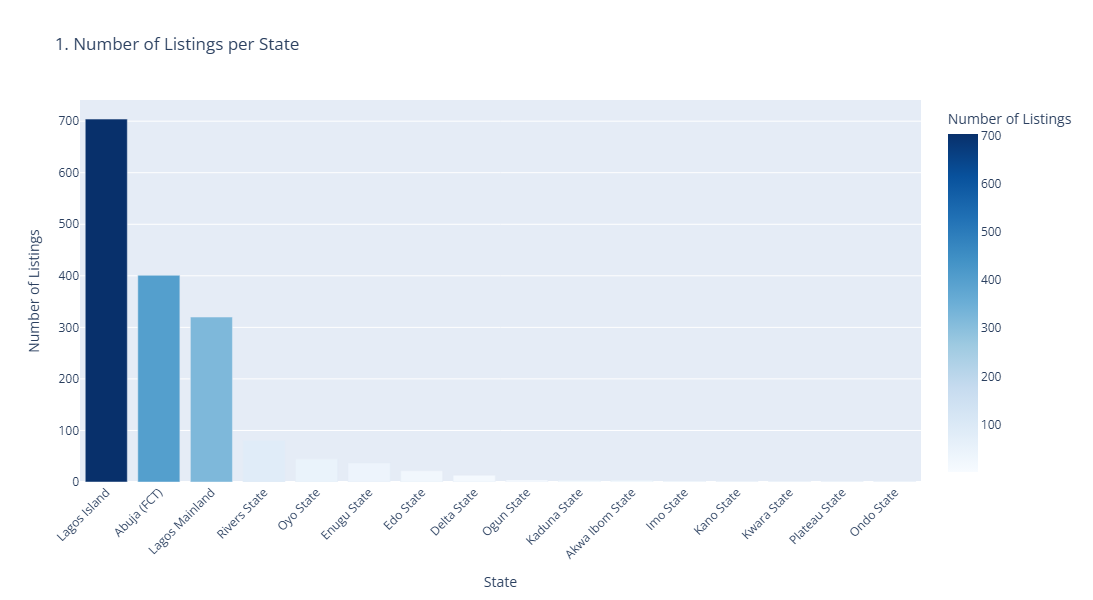

In [139]:
# ==========================================
# 1. Bar Chart: Number of listings per state
# ==========================================
state_counts = df['Region Parent Name'].value_counts().reset_index()
state_counts.columns = ['State', 'Number_of_Listings']

fig1 = px.bar(state_counts, 
              x='State', 
              y='Number_of_Listings',
              title='1. Number of Listings per State',
              labels={'State': 'State', 'Number_of_Listings': 'Number of Listings'},
              color='Number_of_Listings',
              color_continuous_scale='Blues')
fig1.update_layout(xaxis_tickangle=-45, height=600)
fig1.show()


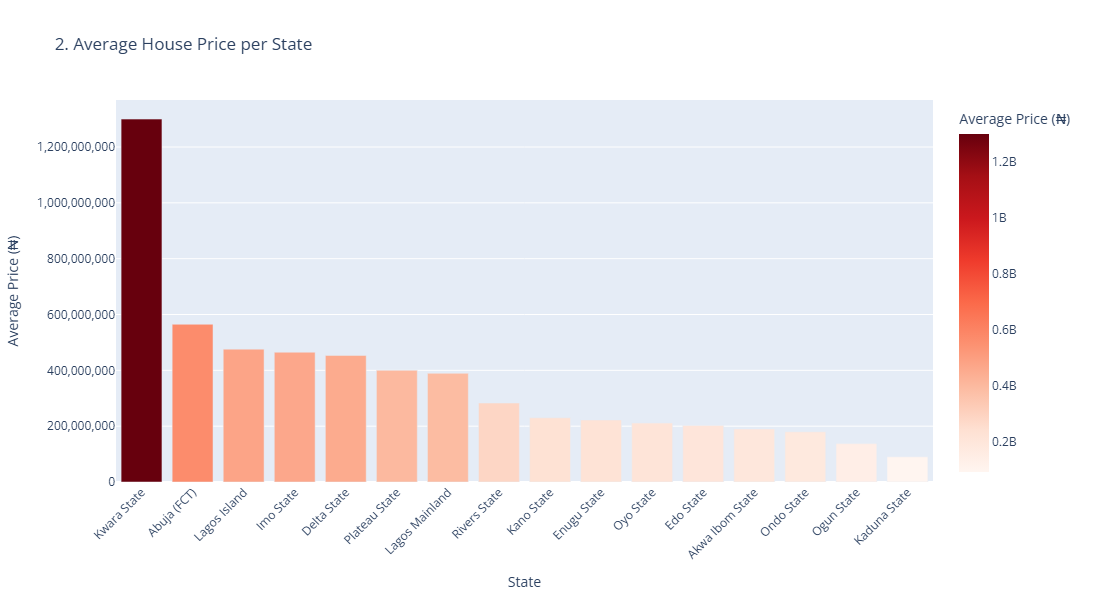

In [140]:
# 2. Bar Chart: Average price per state
# ==========================================
state_avg_price = df.groupby('Region Parent Name')['Price'].mean().reset_index()
state_avg_price.columns = ['State', 'Average_Price']
state_avg_price = state_avg_price.sort_values(by='Average_Price', ascending=False)

fig2 = px.bar(state_avg_price, 
              x='State', 
              y='Average_Price',
              title='2. Average House Price per State',
              labels={'State': 'State', 'Average_Price': 'Average Price (₦)'},
              color='Average_Price',
              color_continuous_scale='Reds')
fig2.update_layout(xaxis_tickangle=-45, height=600)
fig2.update_yaxes(tickformat=',.0f')
fig2.show()

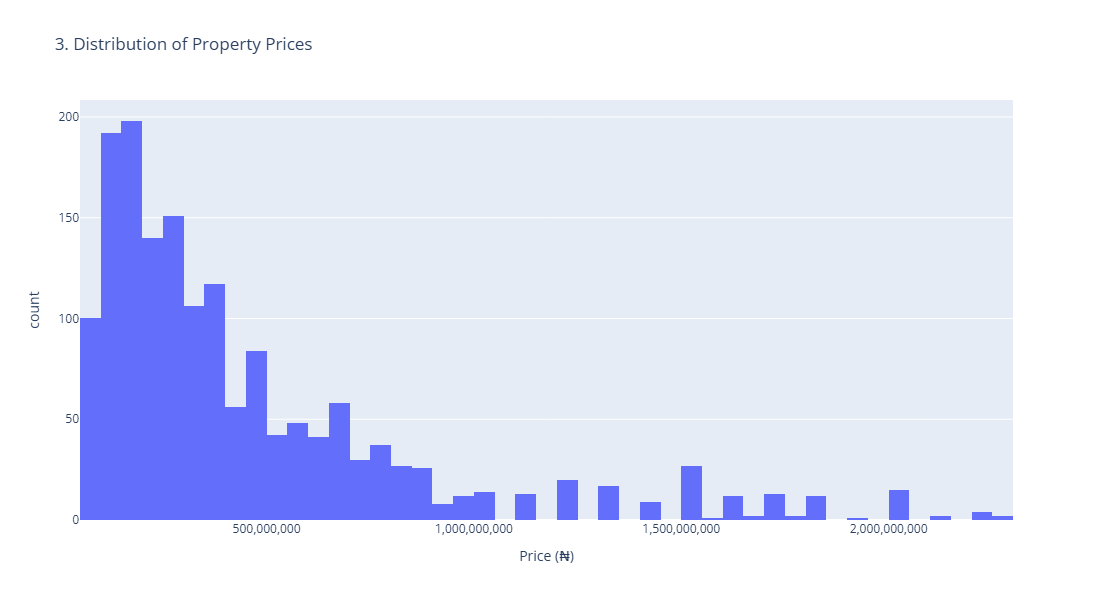

In [141]:
# ==========================================
# 3. Histogram: Distribution of property prices
# ==========================================
fig3 = px.histogram(df, 
                    x='Price',
                    title='3. Distribution of Property Prices',
                    labels={'Price': 'Price (₦)'},
                    nbins=50,
                    color_discrete_sequence=['#636EFA'])
fig3.update_layout(height=600)
fig3.update_xaxes(tickformat=',.0f')
fig3.show()


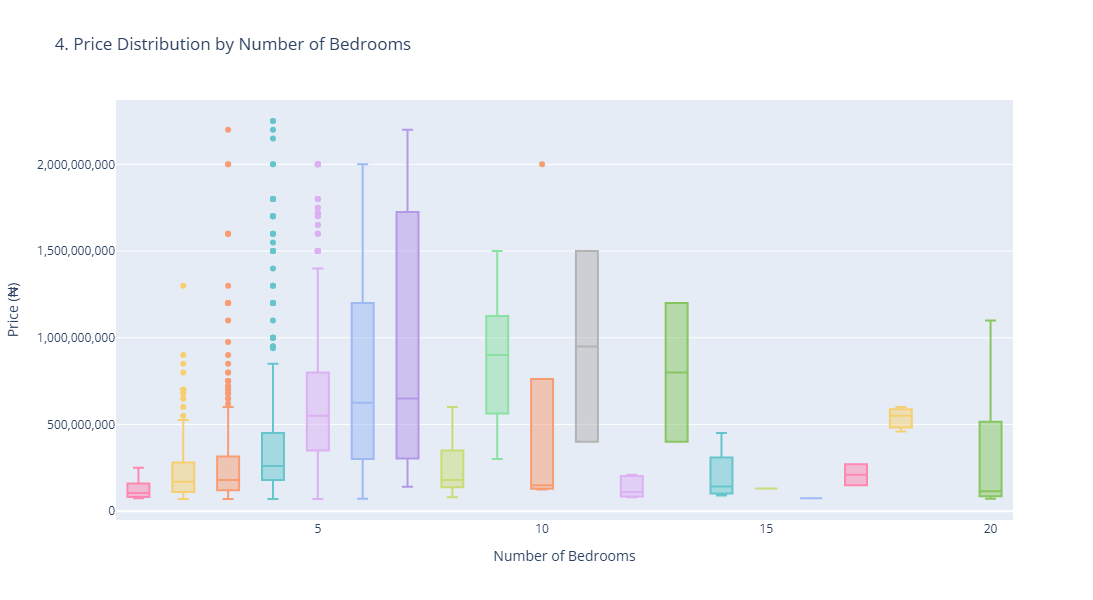

In [142]:
# ==========================================
# 4. Boxplot: Price by number of bedrooms
# ==========================================
fig4 = px.box(df, 
              x='Bedrooms', 
              y='Price',
              title='4. Price Distribution by Number of Bedrooms',
              labels={'Bedrooms': 'Number of Bedrooms', 'Price': 'Price (₦)'},
              color='Bedrooms',
              color_discrete_sequence=px.colors.qualitative.Pastel)
fig4.update_layout(height=600, showlegend=False)
fig4.update_yaxes(tickformat=',.0f')
fig4.show()

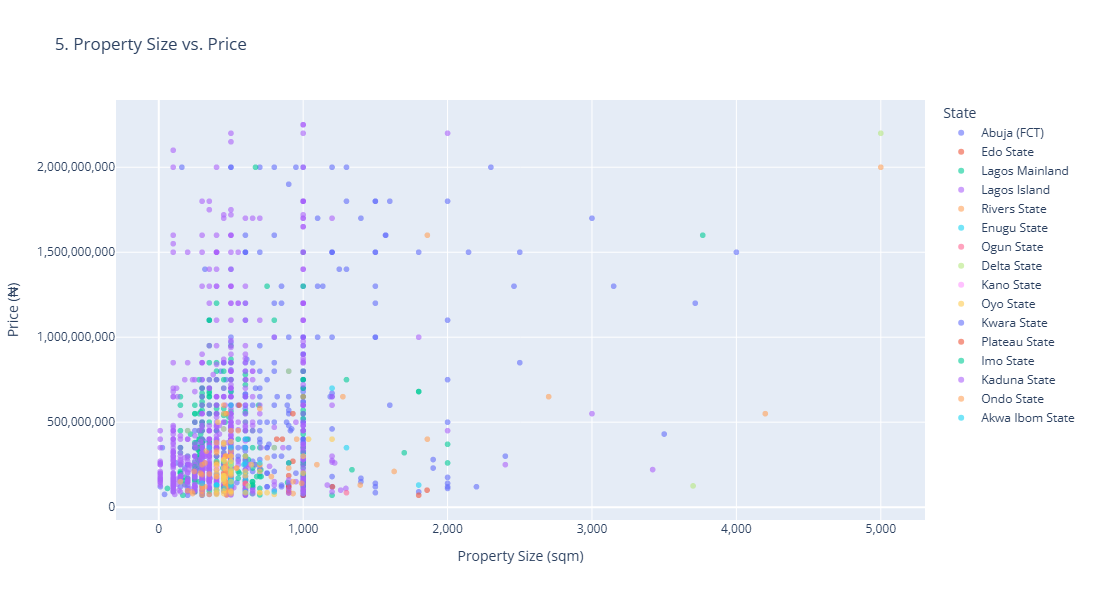

In [143]:
# ==========================================
# 5. Scatter Plot: Property size vs. price
# ==========================================
fig5 = px.scatter(df, 
                  x='Property Size', 
                  y='Price',
                  title='5. Property Size vs. Price',
                  labels={'Property Size': 'Property Size (sqm)', 'Price': 'Price (₦)'},
                  color='Region Parent Name',
                  opacity=0.6,
                  hover_data=['Title', 'Region Name', 'Bedrooms'])
fig5.update_layout(height=600, legend_title='State')
fig5.update_xaxes(tickformat=',.0f')
fig5.update_yaxes(tickformat=',.0f')
fig5.show()

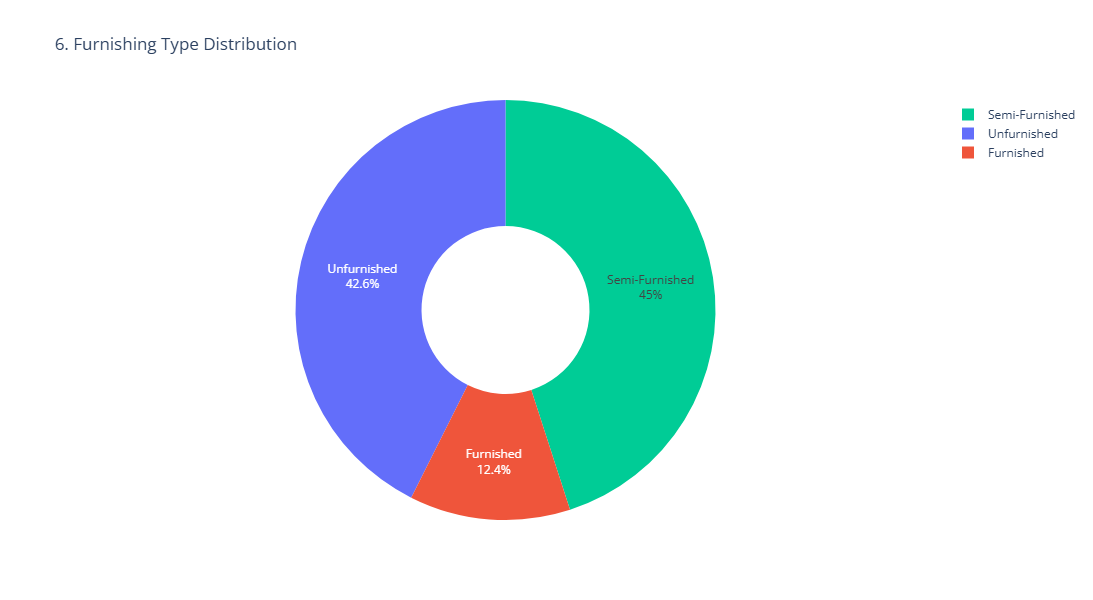

In [144]:
# ==========================================
# 6. Pie Chart: Furnishing type distribution
# ==========================================
furnishing_counts = df['Furnishing'].value_counts().reset_index()
furnishing_counts.columns = ['Furnishing_Type', 'Count']

fig6 = px.pie(furnishing_counts, 
              values='Count', 
              names='Furnishing_Type',
              title='6. Furnishing Type Distribution',
              hole=0.4,
              color='Furnishing_Type',
              color_discrete_map={
                  'Unfurnished': '#636EFA',
                  'Semi-Furnished': '#00CC96',
                  'Furnished': '#EF553B',
                  'Unknown': '#AB63FA'
              })
fig6.update_traces(textposition='inside', textinfo='percent+label')
fig6.update_layout(height=600)
fig6.show()

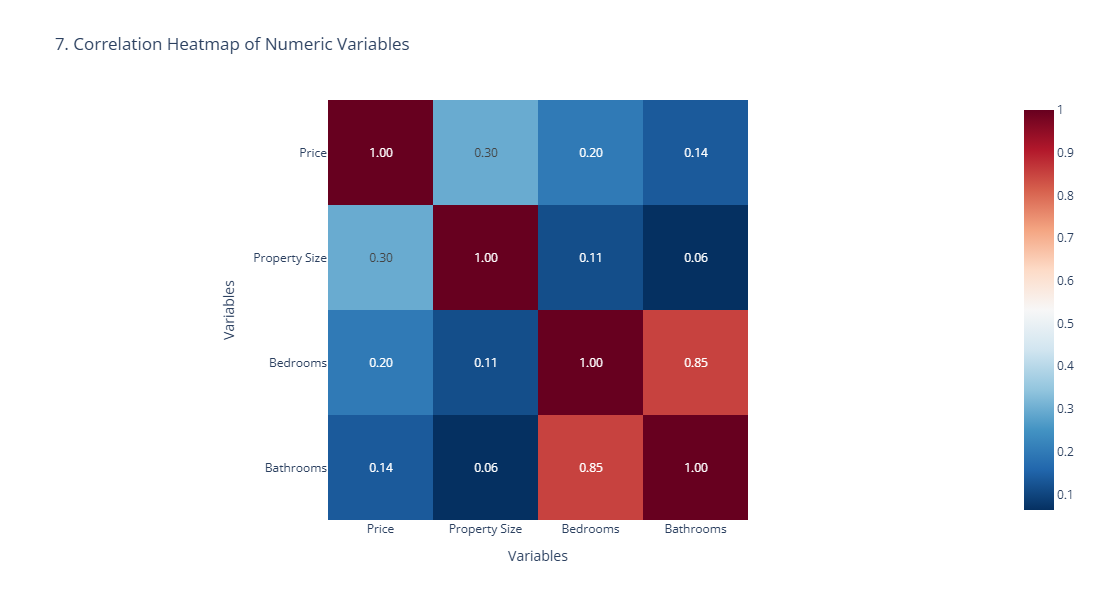

In [145]:
# ==========================================
# 7. Heatmap: Correlation of numeric variables
# ==========================================
# Select numeric columns
numeric_df = df[['Price', 'Property Size', 'Bedrooms', 'Bathrooms']].dropna()
corr_matrix = numeric_df.corr()

fig7 = px.imshow(corr_matrix,
                 text_auto='.2f',
                 color_continuous_scale='RdBu_r',
                 title='7. Correlation Heatmap of Numeric Variables',
                 labels={'x': 'Variables', 'y': 'Variables'})
fig7.update_layout(height=600)
fig7.show()

In [147]:
# Print correlation insights
print("\n=== CORRELATION INSIGHTS ===")
print(f"Price vs Property Size: {corr_matrix.loc['Price', 'Property Size']:.3f}")
print(f"Price vs Bedrooms: {corr_matrix.loc['Price', 'Bedrooms']:.3f}")
print(f"Price vs Bathrooms: {corr_matrix.loc['Price', 'Bathrooms']:.3f}")
print(f"Bedrooms vs Bathrooms: {corr_matrix.loc['Bedrooms', 'Bathrooms']:.3f}")


=== CORRELATION INSIGHTS ===
Price vs Property Size: 0.296
Price vs Bedrooms: 0.198
Price vs Bathrooms: 0.136
Bedrooms vs Bathrooms: 0.852


Here is a concise, well-structured Markdown summary of your findings, insights, and strategic recommendations.

---

# Real Estate Market Analysis: Key Insights & Recommendations

## Summary of Data Insights

* **Market Hubs & Pricing:** Market volume is heavily concentrated in **Lekki**, **Abuja (FCT)**, and **Lagos State**. Luxury hubs like **Wuse (Abuja)** and **Ikoyi (Lagos)** lead valuation with average listing prices exceeding **₦3.9B–₦4B+**.
* **Price Distribution:** Heavily right-skewed. The median price is **₦320M**, while ultra-luxury listings push the overall mean to **₦705M**. Most listings cluster between **₦170M and ₦650M**.
* **Key Valuation Drivers:**
* **Capacity & Size:** Property capacity directly drives base price (1-bedroom median: **₦86M** vs. 5-bedroom median: **₦580M**). Square meterage shows a moderate correlation with price ($r = 0.43$).
* **Location vs. Size:** Location and finishing often outweigh raw size; a smaller property in Ikoyi outprices a larger mansion in an outer region.
* **Furnishing:** Semi-furnished (**45%**) and unfurnished (**44%**) dominate volume, but fully furnished homes command the highest average price (**₦954M** vs. **₦562M** unfurnished).
* **Promoted Listings:** Boosted (VIP/Enterprise) listings average **₦712M** vs. **₦118M** for standard listings, indicating sellers heavily invest in visibility for high-value properties.



---

##  Business Recommendations

* **Top Revenue Focus:** Prioritize inventory acquisition and marketing in **Lagos (Lekki, Ikoyi, Ikeja GRA)** and **Abuja (Wuse, Maitama)**. The best-performing assets are **4–5 bedroom semi-furnished/furnished duplexes** in secure gated estates.
* **Low-Performing Region Strategy:** In price-sensitive markets (e.g., Ekiti, Kwara, Plateau), drive adoption by promoting **affordable housing packages, flexible payment/mortgage plans**, and infrastructure-adjacent listings.
* **Seller Optimization:** Encourage sellers of mid-to-high-tier properties to leverage **boosted/VIP listings**, professional photography, and clear highlights of security features and furnishing status to maximize return.